In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [5]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
x = df.iloc[:,5]
y = df.iloc[:,9]
#Fill null values
df.fillna({"Age":12},inplace=True)
df.fillna({"Fare":34.56},inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,12.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [23]:
#Building the mode 
x_mean = np.mean(x)
y_mean = np.mean(y)

num = 0
den = 0

for i in range(len(x)):
    num += (x[i] - x_mean) * (y[i] - y_mean)
    den += (x[i] -x_mean)**2

m = num / den
c = y_mean - m * x_mean
print(m,c)

0.4316553814445316 20.90211843419268


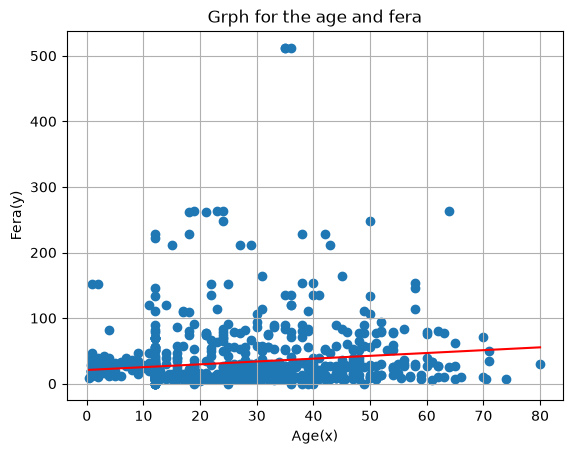

In [25]:
# Making predictions
y_pred = m * x + c

# Scatter plot and draw the least squares estimation
plt.scatter(x, y)
plt.plot([min(x), max(x)], [min(y_pred), max(y_pred)], color="red")
plt.title("Grph for the age and fera")
plt.xlabel("Age(x)")
plt.ylabel("Fera(y)")
plt.grid()
plt.show()

In [30]:
# Calculate residuals (errors)
residuals = y - y_pred

# Number of observations
n = len(x)

# Variance of the errors
sigma_squared = np.sum(residuals ** 2) / (n - 2)

# Variance of the slope
x_variation = np.sum((x - x_mean) ** 2)

var_m = sigma_squared / x_variation

# Calculate Residual Sum of Squares
RSS = np.sum(residuals ** 2)

# Variance of intercept
var_c = sigma_squared * (
    1/n + (x_mean ** 2) / np.sum((x - x_mean) ** 2)
)

print("Residual Sum of Squares:", RSS)
print("Variance of errors:", sigma_squared)
print("Variance of slope:", var_m)
print("Variance of intercept:", var_c)

Residual Sum of Squares: 2161485.879143292
Variance of errors: 2431.367693074569
Variance of slope: 0.01247566961202851
Variance of intercept: 11.28158245099801


In [31]:
# Calculate covariance
covariance = np.sum((x - x_mean) * (y - y_mean)) / (len(x) - 1)

print("Covariance:", covariance)

Covariance: 94.52222359524458


In [32]:
# Center X and Y
x_centered = x - x_mean
y_centered = y - y_mean

# Calculate slope
m = np.sum(x_centered * y_centered) / np.sum(x_centered ** 2)

print("Slope:", m)

Slope: 0.43165538144453225


In [36]:
#Calculate the t-statistic m
SE_m = np.sqrt(var_m)

t = m / SE_m

print("Standard Error:", SE_m)
print("t-statistic:", t)

Standard Error: 0.11169453707334352
t-statistic: 3.8646060295776903


In [40]:
#Confidence Interval for the Slope
from scipy.stats import t

df = len(x) - 2

t_critical = t.ppf(0.975, df)

lower = m - t_critical * SE_m
upper = m + t_critical * SE_m

print("95% Confidence Interval:")
print("Lower:", lower)
print("Upper:", upper)

95% Confidence Interval:
Lower: 0.21243965850876229
Upper: 0.6508711043803022


In [41]:
#Calculate the t-statistic c
SE_c = np.sqrt(var_c)

t_intercept = c / SE_c

print("Standard Error of intercept:", SE_c)
print("t-statistic:", t_intercept)

Standard Error of intercept: 3.3588067004515176
t-statistic: 6.2230786997604985


In [42]:
#Confidence Interval for the Intercept
from scipy.stats import t

df = len(x) - 2

t_critical = t.ppf(0.975, df)

lower = c - t_critical * SE_c
upper = c + t_critical * SE_c

print("95% Confidence Interval for Intercept:")
print("Lower:", lower)
print("Upper:", upper)

95% Confidence Interval for Intercept:
Lower: 14.31000338242879
Upper: 27.49423348595657


In [44]:
#Goodness of Fit of Regression
# Total variation
SST = np.sum((y - y_mean) ** 2)

# Residual variation
#SSE = np.sum((y - y_pred) ** 2)

# R-squared
R2 = 1 - (RSS / SST)

print("R-squared:", R2)

R-squared: 0.016522401271903076


In [45]:
#Predictive Variance
x_new = 25

predictive_variance = sigma_squared * (
    1/n + (x_new - x_mean)**2 /
    np.sum((x - x_mean)**2)
)

print("Predictive variance:", predictive_variance)

Predictive variance: 2.746271174966609


In [46]:
#Predictive Bias
predictive_bias = np.mean(y_pred - y)

print("Predictive bias:", predictive_bias)

Predictive bias: 0.0
